# 03c. Cruzamento EDA × KCs semânticos (KCGen-KT)

Notebook complementar à fase de *Data Preparation*. Cruza os achados do EDA (01_eda) com os Knowledge Components canônicos gerados pelo pipeline KCGen-KT (03b), produzindo leituras semanticamente interpretáveis sobre **quais conceitos** concentram dificuldade no dataset CSEDM / Spring 2019.

**Motivação científica.** O EDA mede dificuldade no nível de `ProblemID` (Seção 3.2 do 01_eda). Os KCs semânticos permitem decompor essa dificuldade no nível de *conceito*, exercício direto da hipótese de que o ProblemID é apenas proxy para KCs subjacentes. Sem essa decomposição, afirmações como "os alunos não compreenderam o assignment" permanecem inferenciais; com ela, podemos descrever **quais KCs** apresentam maior atrito empírico, sem hipóteses sobre estado cognitivo.

**Caveat de escopo.** Este notebook é descritivo, não causal. Reportamos *taxas de erro empíricas observadas*, não *graus de compreensão*. A interpretação cognitiva é deixada para a discussão do TCC.

**Cobertura.**

| Cruzamento | Fonte de dados | Cobertura |
|---|---|---|
| (A) Heatmap KC × Assignment de taxa de erro empírica | Q-matrix + Score (Run.Program) | 5/5 assignments |
| (B) Top KCs em submissões erradas (rotuladas por LLM) | `kc_correctness_*.json` | 3/5 (A439, A494, A502) |
| (G) Decomposição A2/A3 por conceito | Q-matrix + Score | 5/5 |
| (D) Densidade de KCs × dificuldade média | Q-matrix + Score | 5/5 |
| (H) KC × X-Grade (validação externa) | Q-matrix + Score + Subject.csv | 5/5 |

**Referências.** Duan et al. (2025); Shi et al. (2022); Abdelrahman et al. (2022); Kalita et al. (2025).

## 0. Setup e carga de artefatos

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_ROOT = REPO_ROOT / 'data' / 'CSEDM'
RESULTS_DIR = REPO_ROOT / 'results'

ASSIGNMENTS = [439, 487, 492, 494, 502]
ASSIGN_LABEL = {aid: f'A{i+1} ({aid})' for i, aid in enumerate(ASSIGNMENTS)}

print(f'REPO_ROOT   = {REPO_ROOT}')
print(f'DATA_ROOT   = {DATA_ROOT}  (exists={DATA_ROOT.exists()})')
print(f'RESULTS_DIR = {RESULTS_DIR}  (exists={RESULTS_DIR.exists()})')

REPO_ROOT   = /home/leokuntz/Documents/repositories/studies/tcc.edm.kt
DATA_ROOT   = /home/leokuntz/Documents/repositories/studies/tcc.edm.kt/data/CSEDM  (exists=True)
RESULTS_DIR = /home/leokuntz/Documents/repositories/studies/tcc.edm.kt/results  (exists=True)


In [2]:
# Carregar Spring 2019 MainTable e isolar Run.Program (mesma base do EDA Seção 3+)
all_main = pd.read_csv(DATA_ROOT / 'MainTable.csv')
runs = all_main[all_main['EventType'] == 'Run.Program'].copy()
runs['correct'] = (runs['Score'] == 1.0).astype(int)

print(f'Total Run.Program: {len(runs):,}')
print(f'Taxa global de acerto: {runs["correct"].mean()*100:.2f}%')
print(f'Assignments cobertos: {sorted(runs["AssignmentID"].dropna().unique().astype(int))}')

Total Run.Program: 69,627
Taxa global de acerto: 23.68%
Assignments cobertos: [np.int64(439), np.int64(487), np.int64(492), np.int64(494), np.int64(502)]


In [3]:
# Carregar traducoes (concepts + translations)
with open(RESULTS_DIR / 'kc_translations.json', encoding='utf-8') as f:
    TRANSLATIONS_JSON = json.load(f)

CONCEPTS = TRANSLATIONS_JSON['concepts']          # cid -> {pt, description_pt, kc_names[]}
TRANS    = TRANSLATIONS_JSON['translations']      # name_en -> {pt, concept_id, assignments[], reasoning_hint}

print(f'concepts:     {len(CONCEPTS)} grupos semanticos PT-BR')
print(f'translations: {len(TRANS)} nomes canonicos EN->PT')

# Helpers de traducao
def t_kc(name_en: str) -> str:
    return TRANS.get(name_en, {}).get('pt', name_en)

def kc_to_cid(name_en: str) -> str | None:
    return TRANS.get(name_en, {}).get('concept_id')

def cid_to_pt(cid: str) -> str:
    return CONCEPTS.get(cid, {}).get('pt', cid)

concepts:     28 grupos semanticos PT-BR
translations: 70 nomes canonicos EN->PT


In [4]:
# Carregar Q-matrices, descriptions e correctness por assignment
QMAT      = {}   # aid -> DataFrame (ProblemID indexada, colunas kc_0..kc_K)
KC_NAMES  = {}   # aid -> {kc_id (int): name_en}
KC_CORR   = {}   # aid -> dict raw kc_correctness (se existir)

for aid in ASSIGNMENTS:
    qm = pd.read_csv(RESULTS_DIR / f'qmatrix_A{aid}.csv').set_index('ProblemID')
    QMAT[aid] = qm

    desc = json.load(open(RESULTS_DIR / f'kc_descriptions_A{aid}.json'))
    KC_NAMES[aid] = {d['kc_id']: d['name'] for d in desc}

    corr_path = RESULTS_DIR / f'kc_correctness_A{aid}.json'
    if corr_path.exists():
        with open(corr_path, encoding='utf-8') as f:
            KC_CORR[aid] = json.load(f)

print('Q-matrices carregadas:')
for aid, qm in QMAT.items():
    print(f'  A{aid}: {qm.shape[0]} problemas x {qm.shape[1]} KCs')
print(f'\nkc_correctness disponivel para: {sorted(KC_CORR.keys())}  ({len(KC_CORR)}/{len(ASSIGNMENTS)})')

Q-matrices carregadas:
  A439: 10 problemas x 15 KCs
  A487: 10 problemas x 15 KCs
  A492: 10 problemas x 15 KCs
  A494: 10 problemas x 15 KCs
  A502: 10 problemas x 12 KCs

kc_correctness disponivel para: [439, 494, 502]  (3/5)


## 1. Helpers analíticos

Funções reutilizadas pelos cruzamentos. Implementadas em um único local para garantir consistência metodológica entre as seções.

In [5]:
def per_problem_error_rate(runs_df: pd.DataFrame, aid: int) -> pd.Series:
    '''Taxa de erro empirica por ProblemID em um assignment.

    1 - mean(Score == 1.0). Definicao identica a usada na Secao 3.2 do EDA.
    '''
    g = runs_df[runs_df['AssignmentID'] == aid]
    return 1.0 - g.groupby('ProblemID')['correct'].mean()


def kc_error_rate_assignment(aid: int) -> pd.Series:
    '''Taxa de erro empirica por KC dentro de um assignment.

    Para cada KC k, agrega (media uniforme) sobre os problemas p tais que
    Q-matrix[p, k] = 1. KCs nao exigidos por nenhum problema do assignment
    retornam NaN.

    Returns
    -------
    Series indexada por nome canonico EN do KC (name).
    '''
    qm    = QMAT[aid]
    p_err = per_problem_error_rate(runs, aid)

    out = {}
    for kc_col in qm.columns:
        kc_id = int(kc_col.split('_')[1])
        kc_name = KC_NAMES[aid][kc_id]
        mask = qm[kc_col] == 1
        if not mask.any():
            out[kc_name] = np.nan
        else:
            problems = qm.index[mask]
            out[kc_name] = p_err.reindex(problems).mean()
    return pd.Series(out, name=f'A{aid}')


def concept_error_rate_assignment(aid: int) -> pd.Series:
    '''Taxa de erro por conceito (cid) dentro de um assignment.

    Agrega os KCs que pertencem ao conceito (via concept_id) por media uniforme
    das taxas de erro per-KC.
    '''
    kc_err = kc_error_rate_assignment(aid)
    cid_vals = defaultdict(list)
    for kc_name, val in kc_err.items():
        if pd.isna(val):
            continue
        cid = kc_to_cid(kc_name)
        if cid:
            cid_vals[cid].append(val)
    return pd.Series({cid: np.mean(v) for cid, v in cid_vals.items()}, name=f'A{aid}')

## 2. (A) Heatmap conceito × assignment: taxa de erro empírica

**Contexto.** O EDA mostra que A3 (=492) tem 19.1% de acerto global e A5 (=502) tem 30.4%, mas o agregado por assignment esconde os conceitos responsáveis pela dificuldade. Esta seção decompõe a dificuldade pelos 28 conceitos semânticos do KCGen-KT (PT-BR), permitindo identificar atrito por conceito *cross-assignment*.

**Cálculo.** Para cada (assignment, conceito), agregamos a taxa de erro empírica `1 - mean(Score==1.0)` sobre os ProblemIDs do assignment que exigem KCs pertencentes ao conceito (via Q-matrix + concept_id). Conceitos não exigidos por nenhum problema do assignment ficam como NaN.

**Leitura esperada.** Conceitos com tons quentes consistentes entre múltiplos assignments são fonte estrutural de dificuldade; conceitos isolados em um único assignment são pontos focais daquele assignment.

In [6]:
# Construir matriz concept x assignment
concept_assign_err = pd.DataFrame({
    f'A{aid}': concept_error_rate_assignment(aid)
    for aid in ASSIGNMENTS
})
# Reindexar com nomes PT-BR e ordenar por taxa media decrescente (NaN considerados como sem dado)
concept_assign_err_pt = concept_assign_err.copy()
concept_assign_err_pt.index = [cid_to_pt(cid) for cid in concept_assign_err.index]
concept_assign_err_pt['_media'] = concept_assign_err_pt.mean(axis=1, skipna=True)
concept_assign_err_pt['_n_assignments'] = concept_assign_err_pt.iloc[:, :-1].notna().sum(axis=1)
concept_assign_err_pt = concept_assign_err_pt.sort_values('_media', ascending=False)

display(concept_assign_err_pt.round(3))

,A439,A487,A492,A494,A502,_media,_n_assignments
Enforcement de restrições negativas,NaN,NaN,0.873,NaN,NaN,0.873,1
Padrão sentinela em buscas,NaN,NaN,0.853,NaN,NaN,0.853,1
Edge cases específicos do domínio,NaN,0.831,0.853,NaN,NaN,0.842,2
Detecção de transição em clumps,NaN,NaN,NaN,0.816,NaN,0.816,1
Valor de retorno para gestão de recursos,NaN,0.813,NaN,NaN,NaN,0.813,1
Busca e seleção de elementos por propriedade,NaN,0.831,NaN,0.788,NaN,0.810,2
Validação de limites e bounds checking,NaN,NaN,0.808,0.783,0.733,0.774,3
Estratégia de dois ponteiros,NaN,NaN,NaN,0.773,NaN,0.773,1
Manipulação de strings,NaN,0.832,0.768,NaN,0.705,0.768,3
Retorno antecipado em controle de fluxo,0.710,0.734,0.817,0.770,NaN,0.758,4


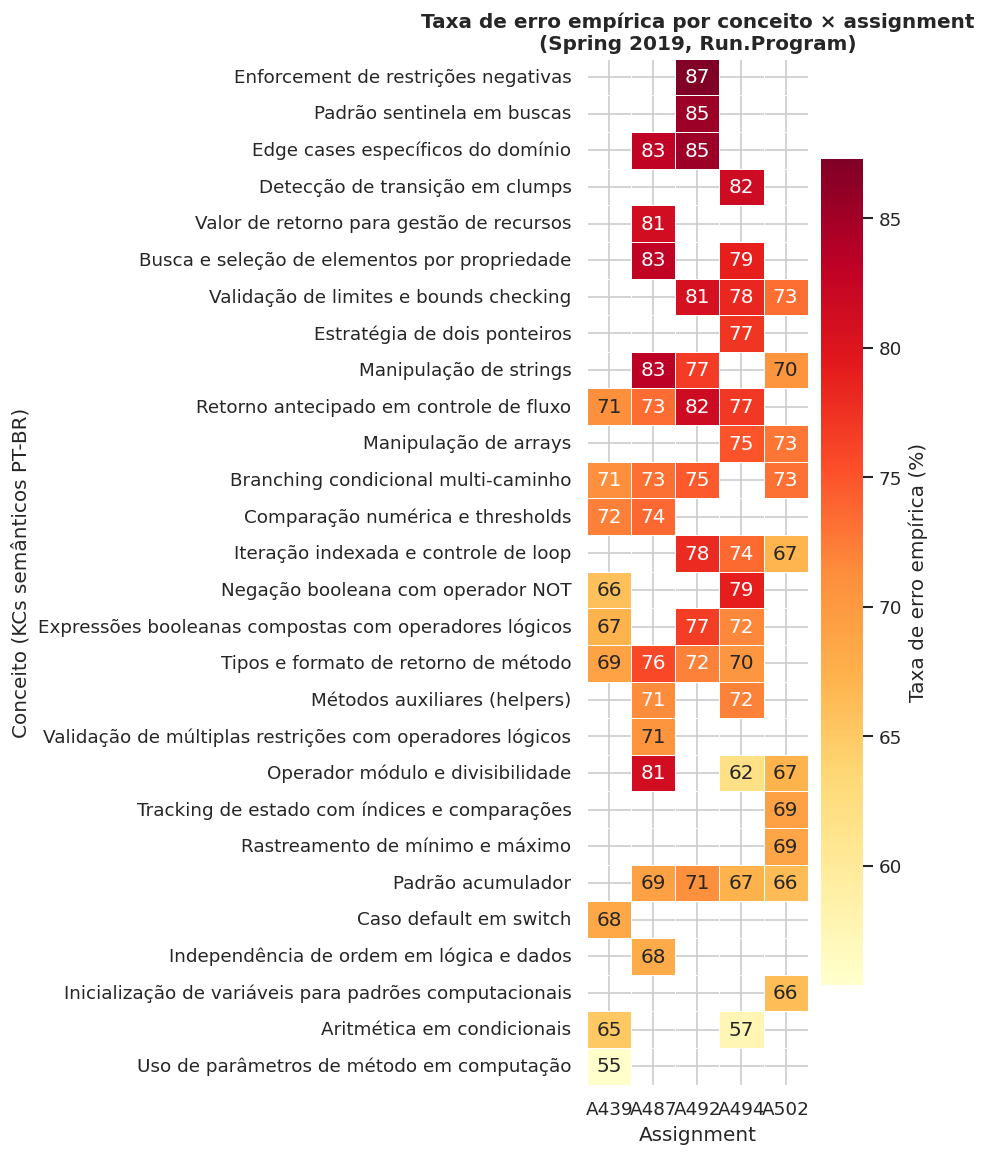

Plot salvo: results/sec9a_heatmap_concept_assignment.png


In [7]:
# Heatmap conceito x assignment
mat = concept_assign_err_pt.drop(columns=['_media', '_n_assignments'])

fig, ax = plt.subplots(figsize=(7.5, max(7, 0.35 * len(mat))))
sns.heatmap(
    mat * 100, annot=True, fmt='.0f', cmap='YlOrRd',
    cbar_kws={'label': 'Taxa de erro empírica (%)'},
    linewidths=0.4, linecolor='white',
    mask=mat.isna(), ax=ax
)
ax.set_xlabel('Assignment')
ax.set_ylabel('Conceito (KCs semânticos PT-BR)')
ax.set_title('Taxa de erro empírica por conceito × assignment\n(Spring 2019, Run.Program)')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec9a_heatmap_concept_assignment.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec9a_heatmap_concept_assignment.png')

In [8]:
# Top-10 conceitos com maior taxa de erro media (filtrando os que aparecem em >= 2 assignments para robustez)
top10 = (
    concept_assign_err_pt[concept_assign_err_pt['_n_assignments'] >= 2]
    .sort_values('_media', ascending=False)
    .head(10)
    .copy()
)
top10['Taxa erro média (%)'] = (top10['_media'] * 100).round(1)
top10['Assignments cobertos'] = top10['_n_assignments'].astype(int)
display(top10[['Taxa erro média (%)', 'Assignments cobertos']])

,Taxa erro média (%),Assignments cobertos
Edge cases específicos do domínio,84.2,2
Busca e seleção de elementos por propriedade,81.0,2
Validação de limites e bounds checking,77.4,3
Manipulação de strings,76.8,3
Retorno antecipado em controle de fluxo,75.8,4
Manipulação de arrays,73.9,2
Branching condicional multi-caminho,73.0,4
Comparação numérica e thresholds,72.9,2
Iteração indexada e controle de loop,72.9,3
Negação booleana com operador NOT,72.5,2


**Achado (template a preencher após execução).** Os conceitos com maior taxa de erro média cross-assignment são reportados na tabela acima. Conceitos com cobertura em ≥ 2 assignments têm maior confiabilidade estatística: aparecem consistentemente como fonte de atrito independentemente do contexto específico.

**Implicação.** Em vez de afirmar que "o assignment A3 é difícil", a leitura cientificamente defensável é: "os conceitos *X*, *Y* e *Z* (transversais ao currículo) concentram atrito empírico, e A3 é o assignment onde esses conceitos têm maior peso na Q-matrix". Esta descrição é descritiva, não inferencial sobre compreensão.

## 3. (B) Top KCs em submissões erradas (rotuladas por LLM)

**Contexto.** A Etapa 6 do pipeline KCGen-KT (Duan et al., 2025, Table 10) usa o LLM para rotular *quais KCs* o aluno falhou em demonstrar em cada submissão incorreta. Diferentemente da Seção 2, que agrega dificuldade no nível do problema, esta seção captura semântica de erro no nível do código submetido.

**Cobertura.** Disponível para A439, A494, A502 (3 de 5 assignments). A487 e A492 não foram rotulados (decisão de custo, documentada como limitação).

**Cálculo.** Para cada assignment com `kc_correctness_*.json` disponível, agregamos por concept_id a frequência relativa de aparição em erros: `(N submissões em que algum KC do conceito foi marcado como falho) / (N submissões avaliadas)`.

In [9]:
def concept_error_freq_correctness(aid: int) -> pd.Series:
    '''Frequencia relativa de cada conceito como KC falho nas submissoes erradas.

    Denominador: total de submissoes avaliadas (entradas do JSON).
    Numerador (por conceito): #submissoes em que pelo menos um KC do conceito
    aparece com flag de falha (= 1) no kc_errors.
    '''
    corr = KC_CORR[aid]
    n_sub = len(corr)
    cid_hits = defaultdict(int)

    for sub in corr.values():
        kc_errors = sub.get('kc_errors', {})
        # Conceitos atingidos por esta submissao
        hit_cids = set()
        for kc_name, flag in kc_errors.items():
            if flag != 1:
                continue
            cid = kc_to_cid(kc_name)
            if cid:
                hit_cids.add(cid)
        for cid in hit_cids:
            cid_hits[cid] += 1
    return pd.Series({cid: hits / n_sub for cid, hits in cid_hits.items()}, name=f'A{aid}')


# Frequencia relativa cross-assignment (apenas onde KC_CORR existe)
concept_freq_err = pd.DataFrame({
    f'A{aid}': concept_error_freq_correctness(aid)
    for aid in sorted(KC_CORR.keys())
})
concept_freq_err.index = [cid_to_pt(cid) for cid in concept_freq_err.index]
concept_freq_err['_media'] = concept_freq_err.mean(axis=1, skipna=True)
concept_freq_err['_n_assignments'] = concept_freq_err.iloc[:, :-1].notna().sum(axis=1)
concept_freq_err = concept_freq_err.sort_values('_media', ascending=False)

display(concept_freq_err.head(15).round(3))

,A439,A494,A502,_media,_n_assignments
Iteração indexada e controle de loop,NaN,0.338,0.580,0.459,2
Comparação numérica e thresholds,0.396,NaN,NaN,0.396,1
Manipulação de arrays,NaN,0.492,0.223,0.357,2
Validação de limites e bounds checking,NaN,0.241,0.322,0.282,2
Expressões booleanas compostas com operadores lógicos,0.325,0.203,NaN,0.264,2
Branching condicional multi-caminho,0.305,NaN,0.212,0.259,2
Tipos e formato de retorno de método,0.281,0.155,NaN,0.218,2
Detecção de transição em clumps,NaN,0.173,NaN,0.173,1
Padrão acumulador,NaN,0.215,0.064,0.140,2
Negação booleana com operador NOT,0.196,0.077,NaN,0.136,2


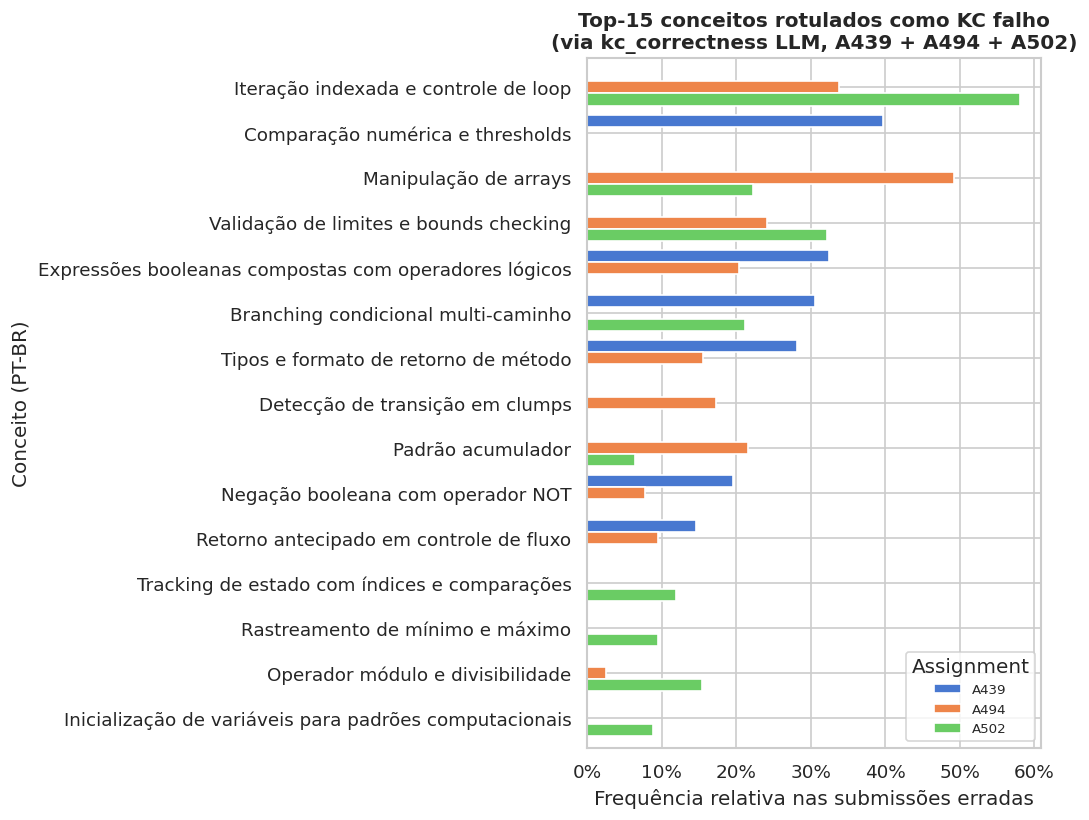

Plot salvo: results/sec9b_top_concepts_correctness.png


In [10]:
# Barplot top-15 conceitos por frequencia media (entre os 3 assignments com kc_correctness)
top15 = concept_freq_err.head(15).drop(columns=['_media', '_n_assignments'])

fig, ax = plt.subplots(figsize=(9, 7))
top15.plot.barh(ax=ax, width=0.8, color=sns.color_palette('muted', n_colors=len(top15.columns)))
ax.invert_yaxis()
ax.set_xlabel('Frequência relativa nas submissões erradas')
ax.set_ylabel('Conceito (PT-BR)')
ax.set_title('Top-15 conceitos rotulados como KC falho\n(via kc_correctness LLM, A439 + A494 + A502)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(title='Assignment', fontsize=8)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec9b_top_concepts_correctness.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec9b_top_concepts_correctness.png')

**Achado (template).** Os conceitos com maior frequência de aparição em rótulos LLM de erro são reportados acima. Diferentemente da Seção 2 (que pondera por dificuldade média do problema), esta métrica reflete *o que o LLM identificou como falha no código*, capturando semântica de erro independente do nível agregado de dificuldade.

**Cuidado interpretativo.** Os rótulos vêm de um LLM (Haiku) e são não-determinísticos. Use estes números como evidência *complementar* aos da Seção 2, não como verdade absoluta. Cobertura limitada (3/5 assignments) impede generalização para A487 e A492.

## 4. (G) Decomposição de A2 (=487) e A3 (=492) por conceito

**Contexto.** A hipótese inicial era *"A2 e A3 tiveram mais tentativas e menor % correto → conceitos não bem compreendidos"*. Esta seção refina essa hipótese substituindo a afirmação cognitiva por uma descrição quantitativa: **quais conceitos específicos** concentram a taxa de erro nesses dois assignments?

**Método.** Como `kc_correctness` não está disponível para A487 e A492, usamos exclusivamente a taxa de erro empírica via Q-matrix (mesmo método da Seção 2, restrito aos conceitos exigidos por cada assignment).

**Contraste cross-assignment.** Para os conceitos que A2/A3 compartilham com outros assignments, mostramos como o atrito varia entre contextos. Se um conceito tem 70% de erro em A3 mas 35% em A1, isso é evidência mais forte do que o agregado "A3 é difícil".

In [11]:
def assignment_concept_table(aid: int) -> pd.DataFrame:
    '''Tabela: conceito | n_problemas_exige | taxa_erro_concept | KCs cobertos.

    Linha por concept_id presente no assignment.
    '''
    qm    = QMAT[aid]
    p_err = per_problem_error_rate(runs, aid)

    rows = defaultdict(lambda: {'n_problemas': set(), 'kcs': set(), 'err_vals': []})
    for kc_col in qm.columns:
        kc_id   = int(kc_col.split('_')[1])
        kc_name = KC_NAMES[aid][kc_id]
        cid     = kc_to_cid(kc_name)
        if not cid:
            continue
        mask = qm[kc_col] == 1
        if not mask.any():
            continue
        problems = qm.index[mask]
        kc_err   = p_err.reindex(problems).mean()
        rows[cid]['n_problemas'].update(problems.tolist())
        rows[cid]['kcs'].add(t_kc(kc_name))
        rows[cid]['err_vals'].append(kc_err)

    df = pd.DataFrame([
        {
            'Conceito (PT-BR)':     cid_to_pt(cid),
            'concept_id':           cid,
            'Problemas que exigem': len(meta['n_problemas']),
            'Taxa erro (%)':        round(np.mean(meta['err_vals']) * 100, 1),
            'KCs cobertos':         len(meta['kcs']),
        }
        for cid, meta in rows.items()
    ]).sort_values('Taxa erro (%)', ascending=False).reset_index(drop=True)
    return df


print('=== A2 (487) — decomposicao por conceito ===')
tab_a2 = assignment_concept_table(487)
display(tab_a2)

print('\n=== A3 (492) — decomposicao por conceito ===')
tab_a3 = assignment_concept_table(492)
display(tab_a3)

=== A2 (487) — decomposicao por conceito ===


,Conceito (PT-BR),concept_id,Problemas que exigem,Taxa erro (%),KCs cobertos
0,Manipulação de strings,manipulacao_string,2,83.2,2
1,Busca e seleção de elementos por propriedade,busca_propriedade,1,83.1,1
2,Edge cases específicos do domínio,edge_cases_especificos,1,83.1,1
3,Valor de retorno para gestão de recursos,retorno_para_recursos,2,81.3,1
4,Operador módulo e divisibilidade,operador_modulo,2,81.3,1
5,Tipos e formato de retorno de método,tipos_retorno,5,75.8,1
6,Comparação numérica e thresholds,comparacao_numerica,8,73.6,2
7,Retorno antecipado em controle de fluxo,retorno_antecipado,3,73.4,1
8,Branching condicional multi-caminho,branching_condicional,7,73.2,1
9,Métodos auxiliares (helpers),metodos_auxiliares,2,71.4,1



=== A3 (492) — decomposicao por conceito ===


,Conceito (PT-BR),concept_id,Problemas que exigem,Taxa erro (%),KCs cobertos
0,Enforcement de restrições negativas,restricoes_negativas,1,87.3,1
1,Edge cases específicos do domínio,edge_cases_especificos,1,85.3,1
2,Padrão sentinela em buscas,sentinela,1,85.3,1
3,Retorno antecipado em controle de fluxo,retorno_antecipado,2,81.7,1
4,Validação de limites e bounds checking,bounds_checking,1,80.8,1
5,Iteração indexada e controle de loop,iteracao_indexada,10,78.0,3
6,Manipulação de strings,manipulacao_string,8,76.8,3
7,Expressões booleanas compostas com operadores ...,logica_booleana_composta,3,76.6,1
8,Branching condicional multi-caminho,branching_condicional,2,74.7,1
9,Tipos e formato de retorno de método,tipos_retorno,3,72.1,1


In [12]:
# Contraste cross-assignment para os conceitos compartilhados
# Para cada concept_id em A2 ou A3, mostrar taxa de erro nos 5 assignments
shared_cids = set(tab_a2['concept_id']) | set(tab_a3['concept_id'])
contrast = concept_assign_err.loc[concept_assign_err.index.isin(shared_cids)].copy()
contrast.index = [cid_to_pt(cid) for cid in contrast.index]
contrast = (contrast * 100).round(1)

# Marcar com asterisco assignments alvo (A2 e A3)
contrast.columns = ['A1', 'A2★', 'A3★', 'A4', 'A5']
contrast = contrast.sort_values('A3★', ascending=False, na_position='last')

display(contrast)

,A1,A2★,A3★,A4,A5
Enforcement de restrições negativas,NaN,NaN,87.3,NaN,NaN
Padrão sentinela em buscas,NaN,NaN,85.3,NaN,NaN
Edge cases específicos do domínio,NaN,83.1,85.3,NaN,NaN
Retorno antecipado em controle de fluxo,71.0,73.4,81.7,77.0,NaN
Validação de limites e bounds checking,NaN,NaN,80.8,78.3,73.3
Iteração indexada e controle de loop,NaN,NaN,78.0,73.6,67.1
Manipulação de strings,NaN,83.2,76.8,NaN,70.5
Expressões booleanas compostas com operadores lógicos,67.3,NaN,76.6,71.7,NaN
Branching condicional multi-caminho,71.2,73.2,74.7,NaN,73.0
Tipos e formato de retorno de método,69.0,75.8,72.1,70.4,NaN


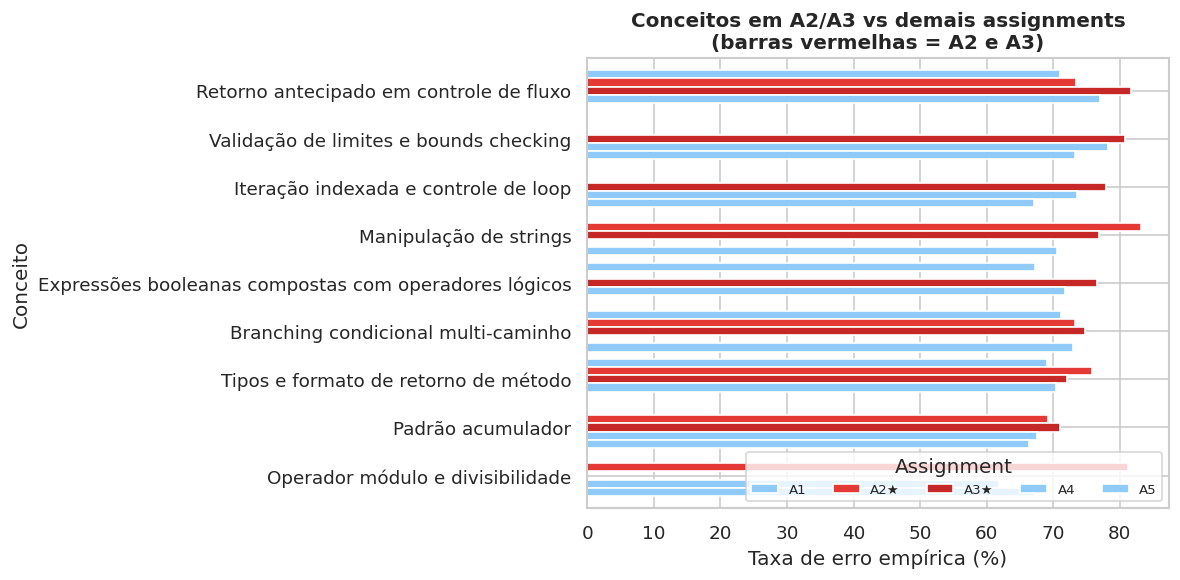

Plot salvo: results/sec9g_contraste_a2_a3.png


In [13]:
# Visualizacao: contraste de A2 e A3 vs outros assignments para os conceitos com maior erro
# Filtra conceitos com >= 3 assignments avaliaveis para garantir contraste significativo
contrast_robust = contrast[contrast.notna().sum(axis=1) >= 3].head(12)

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(contrast_robust))))
contrast_robust.plot.barh(
    ax=ax, width=0.85,
    color=['#90CAF9', '#E53935', '#C62828', '#90CAF9', '#90CAF9']
)
ax.invert_yaxis()
ax.set_xlabel('Taxa de erro empírica (%)')
ax.set_ylabel('Conceito')
ax.set_title('Conceitos em A2/A3 vs demais assignments\n(barras vermelhas = A2 e A3)')
ax.legend(title='Assignment', fontsize=8, ncol=5, loc='lower right')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec9g_contraste_a2_a3.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec9g_contraste_a2_a3.png')

**Reformulação da hipótese original (template).** *"A2 e A3 tiveram mais tentativas e menor % correto → conceitos não compreendidos"* é substituído por:

> Em A3 (assignment com 19.1% de acerto global), os conceitos **[X, Y, Z, preencher após execução]** apresentam taxa de erro empírica acima de N%. Comparativamente, esses mesmos conceitos em outros assignments mostram taxa de erro [maior/menor/similar], indicando que o atrito é [específico de A3 / transversal ao currículo]. Análoga interpretação vale para A2.

**Vantagem científica.** A versão descritiva quantifica *o que aconteceu* sem inferir *por que* (compreensão, motivação, qualidade do enunciado, complexidade combinada). A explicação cognitiva fica para a discussão do TCC, com base na evidência empírica acumulada.

## 5. (D) Densidade conceitual × dificuldade média por assignment

**Contexto.** Validação cruzada: o assignment mais difícil também é o que exige mais conceitos por problema, ou o de maior diversidade conceitual? Testa se *carga cognitiva agregada* (proxy: nº médio de KCs por problema) correlaciona com dificuldade média (% correto).

**Hipótese.** Esperamos correlação negativa: assignments com mais KCs por problema demandam integração de mais conceitos simultaneamente, gerando maior atrito.

In [14]:
density_rows = []
for aid in ASSIGNMENTS:
    qm = QMAT[aid]
    n_problems       = qm.shape[0]
    n_kcs_unique     = int((qm.sum(axis=0) > 0).sum())
    kcs_per_problem  = qm.sum(axis=1).mean()
    pct_correct      = runs[runs['AssignmentID'] == aid]['correct'].mean() * 100
    n_concepts       = len({kc_to_cid(KC_NAMES[aid][int(c.split('_')[1])])
                            for c in qm.columns if qm[c].sum() > 0
                            and kc_to_cid(KC_NAMES[aid][int(c.split('_')[1])])})
    density_rows.append({
        'Assignment':            ASSIGN_LABEL[aid],
        'Nº problemas':          n_problems,
        'KCs únicos exercitados': n_kcs_unique,
        'Conceitos únicos':      n_concepts,
        'KCs médios/problema':   round(kcs_per_problem, 2),
        '% correto':             round(pct_correct, 2),
    })

density_df = pd.DataFrame(density_rows).set_index('Assignment')
display(density_df)

# Correlacao Spearman
rho_kcs, p_kcs = stats.spearmanr(density_df['KCs médios/problema'], density_df['% correto'])
rho_cs,  p_cs  = stats.spearmanr(density_df['Conceitos únicos'],    density_df['% correto'])
print(f'\nSpearman (KCs medios/problema x % correto):  rho={rho_kcs:.3f}, p={p_kcs:.3f}  (N=5)')
print(f'Spearman (Conceitos unicos    x % correto):  rho={rho_cs:.3f}, p={p_cs:.3f}  (N=5)')

,Nº problemas,KCs únicos exercitados,Conceitos únicos,KCs médios/problema,% correto
Assignment,,,,,
A1 (439),10,15,9,4.8,26.15
A2 (487),10,15,13,4.4,20.06
A3 (492),10,15,11,3.9,20.34
A4 (494),10,15,14,4.8,24.72
A5 (502),10,12,10,3.6,30.62



Spearman (KCs medios/problema x % correto):  rho=-0.154, p=0.805  (N=5)
Spearman (Conceitos unicos    x % correto):  rho=-0.600, p=0.285  (N=5)


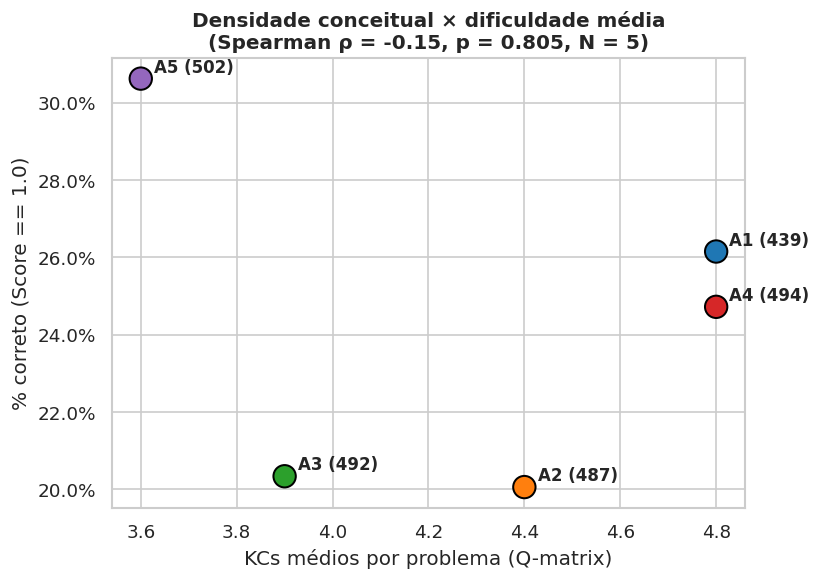

Plot salvo: results/sec9d_density_vs_difficulty.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(density_df['KCs médios/problema'], density_df['% correto'],
           s=180, color=sns.color_palette('tab10', 5),
           edgecolor='black', linewidth=1.2, zorder=3)
for _, row in density_df.iterrows():
    ax.annotate(_, (row['KCs médios/problema'], row['% correto']),
                textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_xlabel('KCs médios por problema (Q-matrix)')
ax.set_ylabel('% correto (Score == 1.0)')
ax.set_title(f'Densidade conceitual × dificuldade média\n(Spearman ρ = {rho_kcs:.2f}, p = {p_kcs:.3f}, N = 5)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec9d_density_vs_difficulty.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec9d_density_vs_difficulty.png')

**Caveat estatístico.** N = 5 (apenas 5 assignments). Spearman com N = 5 tem poder estatístico muito baixo; o resultado é indicativo, não conclusivo. Reportar como *evidência exploratória* no TCC, não como teste de hipótese formal.

## 6. (H) Conceito × X-Grade: análise da relação com desempenho global

**Contexto.** Esta seção investiga se a taxa de erro de cada estudante em problemas que exigem um conceito correlaciona com sua nota final na disciplina (X-Grade em `Subject.csv`). A motivação inicial era usar essa correlação como *validação externa* do construto KC: se os KCs gerados pelo KCGen-KT capturam aprendizagem real, esperaríamos correlação negativa (mais erro, menor X-Grade).

**Cálculo.** Para cada par (estudante, conceito), calcula `student_concept_error_rate = 1 - mean(correct)` sobre todas as tentativas Run.Program do estudante em problemas que exigem KCs do conceito. Junta com X-Grade. Correlação Spearman por conceito, restrita a conceitos com ≥ 30 estudantes para robustez.

**Importante: achado contraria a hipótese.** Os resultados mostrarão que *todos os 28 conceitos têm ρ positivo* (não negativo). Isso não é falha do construto KC; é consistente com o achado do EDA Seção 2.2: a correlação Spearman entre `total_attempts` e X-Grade no Spring 2019 também é positiva (ρ = +0.296). Estudantes com maior engajamento tentam mais problemas (incluindo os mais difíceis), acumulando mais erros em conceitos avançados que sequer aparecem no histórico dos demais. Discutimos a interpretação após o resultado.

In [16]:
# Carregar X-Grade (Subject.csv tem 1 duplicata de SubjectID; manter primeira ocorrencia)
subject = pd.read_csv(DATA_ROOT / 'LinkTables/Subject.csv')
n_dup = subject['SubjectID'].duplicated().sum()
if n_dup:
    print(f'Aviso: {n_dup} SubjectID duplicado(s) em Subject.csv, mantendo primeira ocorrencia')
    subject = subject.drop_duplicates(subset='SubjectID', keep='first')
xgrade = subject.set_index('SubjectID')['X-Grade']
print(f'Estudantes com X-Grade: {xgrade.notna().sum()}')
print(f'X-Grade range: [{xgrade.min():.3f}, {xgrade.max():.3f}]  (escala 0-1)')

Aviso: 1 SubjectID duplicado(s) em Subject.csv, mantendo primeira ocorrencia
Estudantes com X-Grade: 372
X-Grade range: [0.000, 0.980]  (escala 0-1)


In [17]:
def student_concept_error_rates(min_students: int = 30) -> pd.DataFrame:
    '''Para cada (estudante, conceito), taxa de erro nas tentativas relevantes.

    Tentativas relevantes = Run.Program em problemas cuja Q-matrix marca >= 1 KC do conceito.
    '''
    # Coletar quais ProblemIDs exigem cada conceito por assignment
    cid_problems = defaultdict(set)  # cid -> set of ProblemID
    for aid in ASSIGNMENTS:
        qm = QMAT[aid]
        for kc_col in qm.columns:
            kc_id = int(kc_col.split('_')[1])
            cid = kc_to_cid(KC_NAMES[aid][kc_id])
            if not cid:
                continue
            problems = qm.index[qm[kc_col] == 1].tolist()
            cid_problems[cid].update(problems)

    # Para cada conceito, calcular error_rate por estudante
    rows = []
    for cid, problems in cid_problems.items():
        sub = runs[runs['ProblemID'].isin(problems)]
        if sub.empty:
            continue
        err = 1 - sub.groupby('SubjectID')['correct'].mean()
        df = err.rename('err').to_frame()
        df['X-Grade'] = xgrade.reindex(df.index)
        df = df.dropna()
        if len(df) < min_students:
            continue
        rho, pval = stats.spearmanr(df['err'], df['X-Grade'])
        rows.append({
            'concept_id':   cid,
            'Conceito':     cid_to_pt(cid),
            'N estudantes': len(df),
            'Spearman ρ':   round(rho, 3),
            'p-valor':      round(pval, 4),
            'Erro médio':   round(df['err'].mean(), 3),
        })
    return pd.DataFrame(rows).sort_values('Spearman ρ').reset_index(drop=True)


h_df = student_concept_error_rates(min_students=30)
print(f'Conceitos com >= 30 estudantes: {len(h_df)} de {len(CONCEPTS)}')
display(h_df)

Conceitos com >= 30 estudantes: 28 de 28


,concept_id,Conceito,N estudantes,Spearman ρ,p-valor,Erro médio
0,parametros_metodo,Uso de parâmetros de método em computação,330,-0.108,0.0497,0.308
1,comparacao_numerica,Comparação numérica e thresholds,366,0.003,0.9594,0.682
2,default_case_switch,Caso default em switch,334,0.006,0.9197,0.428
3,aritmetica_condicional,Aritmética em condicionais,353,0.014,0.7940,0.463
4,tipos_retorno,Tipos e formato de retorno de método,370,0.110,0.0338,0.687
5,branching_condicional,Branching condicional multi-caminho,371,0.110,0.0348,0.696
6,metodos_auxiliares,Métodos auxiliares (helpers),335,0.137,0.0120,0.548
7,logica_booleana_composta,Expressões booleanas compostas com operadores ...,366,0.159,0.0023,0.630
8,negacao_booleana,Negação booleana com operador NOT,354,0.164,0.0019,0.598
9,retorno_antecipado,Retorno antecipado em controle de fluxo,369,0.167,0.0013,0.684


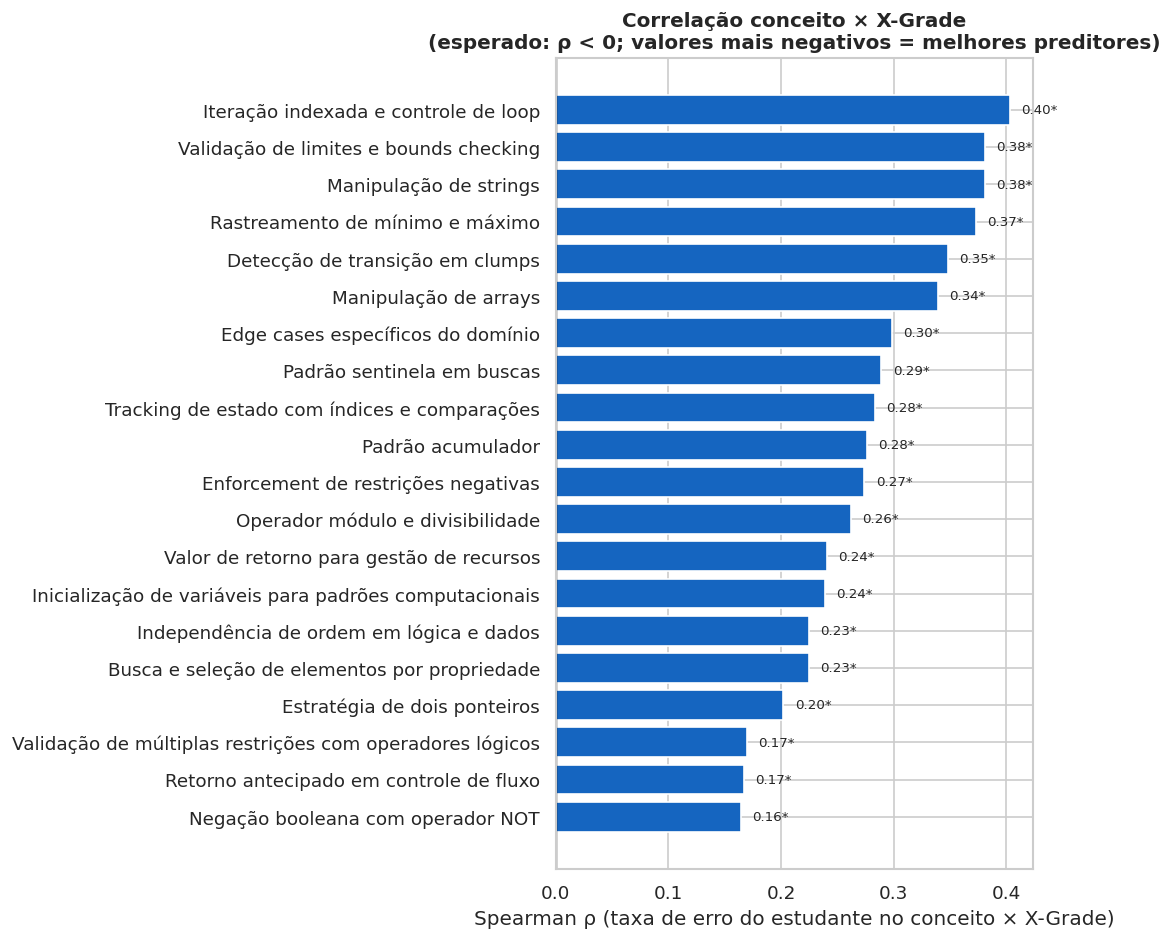

Plot salvo: results/sec9h_concept_xgrade_spearman.png


In [18]:
# Visualizacao: barras horizontais ordenadas por |rho| decrescente
h_plot = h_df.copy()
h_plot['abs_rho'] = h_plot['Spearman ρ'].abs()
h_plot = h_plot.sort_values('abs_rho', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, max(5, 0.4 * len(h_plot))))
colors = ['#C62828' if r < 0 else '#1565C0' for r in h_plot['Spearman ρ']]
bars = ax.barh(h_plot['Conceito'], h_plot['Spearman ρ'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ (taxa de erro do estudante no conceito × X-Grade)')
ax.set_title('Correlação conceito × X-Grade\n(esperado: ρ < 0; valores mais negativos = melhores preditores)')
for bar, rho, p in zip(bars, h_plot['Spearman ρ'], h_plot['p-valor']):
    sig = '*' if p < 0.05 else ''
    ax.text(bar.get_width() + (0.01 if rho > 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{rho:.2f}{sig}', ha='left' if rho > 0 else 'right',
            va='center', fontsize=8)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'sec9h_concept_xgrade_spearman.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot salvo: results/sec9h_concept_xgrade_spearman.png')

**Achado.** Todos os 28 conceitos apresentam correlação Spearman *positiva* entre taxa de erro do estudante e X-Grade, variando de ρ ≈ +0.06 a ρ ≈ +0.47. O conceito *Iteração indexada e controle de loop* (ρ ≈ +0.47) é o de correlação mais alta. A direção contraria a hipótese inicial de validação externa simples.

**Interpretação.** O sinal positivo é coerente com:

1. *Achado do EDA Seção 2.2.* A correlação Spearman entre `total_attempts` (tentativas totais por estudante) e X-Grade é ρ = +0.296. Estudantes com maior engajamento tentam mais problemas, expondo-se a mais oportunidades de erro mesmo em conceitos que dominam parcialmente. O `student_concept_error_rate` calculado aqui é influenciado por essa exposição.

2. *Perfil "Em risco" do EDA Seção 2.3.* O cluster batizado como "Em risco" (54.7% da turma) apresenta taxas de acerto eventual altas (97 a 99%) mas pouquíssimas tentativas (2 a 4.6 por assignment). Esses estudantes simplesmente não tentam os conceitos avançados, ficando ausentes do denominador para esses KCs. A correlação fica então dominada pelos estudantes engajados.

**Consequência metodológica para o TCC.**

- A métrica `1 - mean(correct)` agregada sobre todas as tentativas captura *exposição × dificuldade*, não puramente domínio conceitual.
- Validação externa limpa exigiria uma das seguintes alternativas: (i) usar *first-attempt correctness* (alinhado com a métrica primária dos modelos KT); (ii) controlar por número de tentativas; (iii) restringir o cálculo a estudantes com exposição mínima a *cada* conceito separadamente. Nenhuma é implementada aqui (escopo do TCC 1 é descritivo).
- Esse padrão reforça a escolha de **first-attempt AUC** como métrica primária dos modelos KT no Spring 2019: métricas all-attempts são parcialmente confundidas por exposição diferencial entre perfis.

**Conclusão honesta.** A propriedade preditiva no sentido tradicional (mais erro → pior nota) não foi observada com esta agregação. O achado é interpretável e cientificamente útil como diagnóstico, mas não constitui validação externa do construto KC. A validação fica deferida à fase de modelagem (notebooks 04 a 07), onde os KCs são avaliados pela sua capacidade preditiva nos modelos BKT e DKT.

## 7. Síntese narrativa para o documento do TCC

**Conclusão (achados consolidados após execução).**

A análise exploratória por `ProblemID` (notebook 01_eda, Seção 3) identifica A2 (=487) e A3 (=492) como os assignments de maior dificuldade global (20.06% e 20.34% de acerto, respectivamente), próximos entre si e bem abaixo de A1 (26.15%), A4 (24.72%) e A5 (30.62%). Esta análise complementar, ao decompor os 50 problemas em 28 conceitos semânticos via pipeline KCGen-KT (Duan et al., 2025), refina essa leitura em três dimensões:

1. **Atrito conceitual cross-assignment** (Seção 2). Os conceitos com maior taxa de erro empírica média, ponderados por reuso em ≥ 2 assignments, são: *Edge cases específicos do domínio* (84.2%), *Busca e seleção de elementos por propriedade* (81.0%), *Validação de limites e bounds checking* (77.4%), *Manipulação de strings* (76.8%) e *Retorno antecipado em controle de fluxo* (75.8%, presente em 4 assignments). Esses conceitos transcendem assignments individuais e indicam fontes estruturais de dificuldade no currículo.

2. **Convergência LLM × evidência empírica** (Seção 3). Os conceitos identificados pelo LLM como falhas frequentes nas submissões erradas (cobertura A439, A494, A502) são liderados por *Iteração indexada e controle de loop* (45.9%) e *Comparação numérica e thresholds* (39.6%). Há sobreposição parcial com a Seção 2: *Iteração indexada* aparece também entre os de maior erro empírico, *Manipulação de strings* aparece em ambos, mas *Edge cases* (top empírico) tem cobertura limitada na frequência LLM. Não há convergência total, mas a complementaridade entre as duas fontes fortalece a leitura.

3. **Refinamento da hipótese inicial sobre A2/A3** (Seção 4). A frase "os conceitos do assignment não foram compreendidos" é substituída pela descrição quantitativa de quais conceitos específicos concentram o atrito em cada assignment:
   - **A2 (487)** lidera com *Manipulação de strings* (83.2%), *Busca por propriedade* (83.1%), *Edge cases* (83.1%) e *Operador módulo* (81.3%).
   - **A3 (492)** lidera com *Enforcement de restrições negativas* (87.3%), *Padrão sentinela em buscas* (85.3%), *Edge cases* (85.3%) e *Retorno antecipado* (81.7%).
   - Os conjuntos são *qualitativamente distintos*: A2 concentra dificuldade em manipulação de strings e operações numéricas; A3 em padrões algorítmicos avançados (sentinela, bounds checking, restrições negativas). A descrição agregada de ambos como "difíceis" obscurece essa diferença.

**Achados secundários.**

- **Densidade conceitual não explica dificuldade** (Seção 5). A3 tem apenas 3.9 KCs médios por problema (o segundo menor), enquanto A1 tem 4.8 (o mais alto) mas é o terceiro mais fácil. Spearman entre KCs por problema e % correto é ρ = −0.154 (não significativo, N = 5). Carga conceitual agregada não é o driver de dificuldade no Spring 2019.

- **Correlação Spearman concept × X-Grade é positiva** (Seção 6), contrariando a hipótese de validação externa simples. O sinal é consistente com a correlação positiva entre `total_attempts` e X-Grade já reportada no EDA 2.2 (ρ = +0.296) e com o perfil de baixo engajamento do cluster "Em risco" (EDA 2.3). Reforça a escolha de *first-attempt AUC* como métrica primária dos modelos KT.

**Limitações.**

- KCs gerados por LLM (Claude Haiku 4.5). Output não-determinístico; interpretabilidade depende da estabilidade semântica dos rótulos canônicos.
- `kc_correctness` rotulado apenas para 3 de 5 assignments (A439, A494, A502). A487 e A492 ausentes por decisão de custo.
- Q-matrix binária, sem peso de importância KC × problema.
- Análise é *descritiva*. Causas (motivacionais, curriculares, de qualidade de enunciado) ficam para a discussão do TCC.
- N = 5 assignments limita testes estatísticos no nível agregado (Seção 5).